In [1]:
!nvidia-smi

Thu Dec  4 15:38:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import cv2
import os

In [3]:
data_path="/content/drive/MyDrive/brain_tumor_dataset"

In [4]:
categories=os.listdir(data_path)
categories

['yes', 'no']

In [5]:
labels=[i for i in range(len(categories))]
labels

[0, 1]

In [6]:
label_dict=dict(zip(categories,labels))
label_dict

{'yes': 0, 'no': 1}

In [7]:
img_size=100
data=[]
target=[]

for category in categories:
  folder_path=os.path.join(data_path,category)
  #print(folder_path)
  image_names=os.listdir(folder_path)
  #print(image_names)                         accessing

  for img_name in image_names:
    img_path=os.path.join(folder_path,img_name)
    img=cv2.imread(img_path)

    try:
      gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
      resized=cv2.resize(gray,(img_size,img_size))
      data.append(resized)
      target.append(label_dict[category])

    except Exception as e:
      print('Exception :',e)



In [8]:
len(data)

253

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)
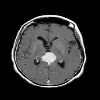

In [9]:
data[7]

In [10]:
data[89][50]

array([  3,  11, 187, 233,  39,  44,   0,   0,   2, 123, 129, 117, 118,
       110, 109, 116, 111, 120, 125, 160, 181, 177, 186, 169, 173, 191,
       182, 132, 120, 111, 104,  98,  88,  94,  95,  95,  92,  87,  87,
       113, 117, 120, 159, 151, 140, 184, 196, 160, 190, 105, 189, 224,
       189, 173, 170, 175, 167, 150, 121, 109, 103, 104,  89,  90,  86,
        86,  91, 108, 116, 121, 110,  89,  89,  95, 101, 119, 144, 127,
       121, 160, 130, 126, 125, 168, 183, 166, 143, 174,  26,   2,   4,
         4,   3, 187, 233,  75,   5,   2,   1,   1], dtype=uint8)

imshow=to show the numpy array

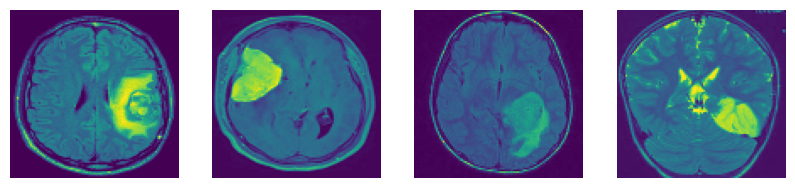

In [11]:
#magic command
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(data[i])
  plt.axis('off')
plt.show()

In [12]:
import numpy as np
data=np.array(data)/255.0

In [13]:
data[89][50]

array([0.01176471, 0.04313725, 0.73333333, 0.91372549, 0.15294118,
       0.17254902, 0.        , 0.        , 0.00784314, 0.48235294,
       0.50588235, 0.45882353, 0.4627451 , 0.43137255, 0.42745098,
       0.45490196, 0.43529412, 0.47058824, 0.49019608, 0.62745098,
       0.70980392, 0.69411765, 0.72941176, 0.6627451 , 0.67843137,
       0.74901961, 0.71372549, 0.51764706, 0.47058824, 0.43529412,
       0.40784314, 0.38431373, 0.34509804, 0.36862745, 0.37254902,
       0.37254902, 0.36078431, 0.34117647, 0.34117647, 0.44313725,
       0.45882353, 0.47058824, 0.62352941, 0.59215686, 0.54901961,
       0.72156863, 0.76862745, 0.62745098, 0.74509804, 0.41176471,
       0.74117647, 0.87843137, 0.74117647, 0.67843137, 0.66666667,
       0.68627451, 0.65490196, 0.58823529, 0.4745098 , 0.42745098,
       0.40392157, 0.40784314, 0.34901961, 0.35294118, 0.3372549 ,
       0.3372549 , 0.35686275, 0.42352941, 0.45490196, 0.4745098 ,
       0.43137255, 0.34901961, 0.34901961, 0.37254902, 0.39607

In [14]:
data.ndim

3

In [15]:
data=np.reshape(data,(data.shape[0],img_size,img_size,1))
target=np.array(target)

In [16]:
data.ndim

4

In [17]:
target[200]

np.int64(1)

In [18]:
from tensorflow.keras.utils import to_categorical
new_target=to_categorical(target)

In [19]:
new_target[200]

array([0., 1.])

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data,new_target,test_size=0.1,random_state=42)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Flatten,Dropout
from tensorflow.keras.layers import Conv2D,MaxPooling2D

model=Sequential()

model.add(Conv2D(200,(3,3),input_shape=data.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(100,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(50,activation='relu'))
model.add(Dense(2,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dropout=to reduce overfritting  o\p=0 0r 1

In [22]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [23]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,validation_split=0.2)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 680ms/step - accuracy: 0.4520 - loss: 0.7525 - val_accuracy: 0.6923 - val_loss: 0.6558
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7627 - loss: 0.5857 - val_accuracy: 0.6923 - val_loss: 0.6732
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7703 - loss: 0.5310 - val_accuracy: 0.6923 - val_loss: 0.6113
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7740 - loss: 0.5350 - val_accuracy: 0.6923 - val_loss: 0.6189
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8166 - loss: 0.4292 - val_accuracy: 0.6923 - val_loss: 0.5929
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8080 - loss: 0.4226 - val_accuracy: 0.7308 - val_loss: 0.5610
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8288 - loss: 0.3905 - val_accuracy: 0.7692 - val_loss: 0.5591
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8757 - loss: 0.3521 - val_accuracy: 0.7692 - val_loss: 0.535

In [24]:
history.history['loss']

[0.7318153381347656,
 0.5723921060562134,
 0.5188573598861694,
 0.5106328129768372,
 0.4510316848754883,
 0.42790767550468445,
 0.3971312642097473,
 0.3757535219192505,
 0.32049861550331116,
 0.2757575511932373]

In [25]:
history.history['val_loss']

[0.6557658314704895,
 0.6731984615325928,
 0.61130690574646,
 0.6188846230506897,
 0.5928527116775513,
 0.5609558820724487,
 0.5590974688529968,
 0.5356134176254272,
 0.4669027626514435,
 0.5371789336204529]

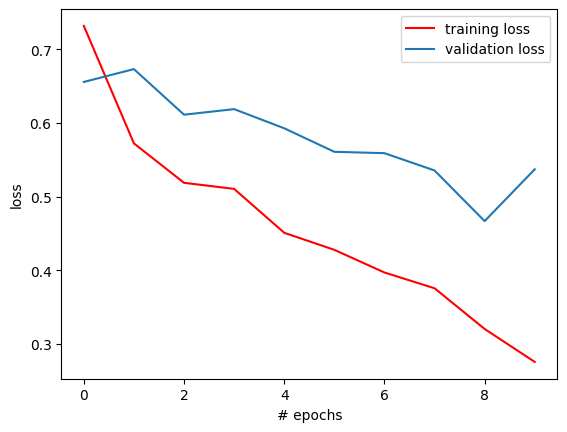

In [26]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'],'r',label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

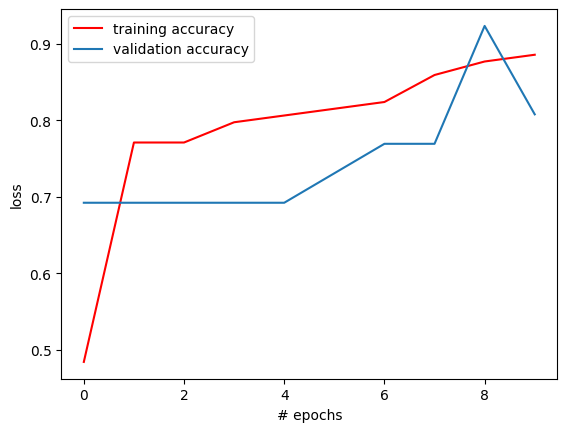

In [27]:
plt.plot(history.history['accuracy'],'r',label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [28]:
y_predicted = model.predict(x_test)
y_predicted


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


array([[3.38692917e-04, 9.99661326e-01],
       [9.41735804e-01, 5.82641549e-02],
       [8.62343252e-01, 1.37656733e-01],
       [9.91450012e-01, 8.54993518e-03],
       [5.53592265e-01, 4.46407795e-01],
       [1.88412189e-01, 8.11587811e-01],
       [7.74871111e-01, 2.25128889e-01],
       [3.03071905e-02, 9.69692767e-01],
       [9.79671299e-01, 2.03287061e-02],
       [6.03119254e-01, 3.96880746e-01],
       [8.67210448e-01, 1.32789612e-01],
       [6.61700130e-01, 3.38299841e-01],
       [4.09354642e-03, 9.95906472e-01],
       [6.62080228e-01, 3.37919801e-01],
       [8.95626664e-01, 1.04373299e-01],
       [7.05096781e-01, 2.94903219e-01],
       [4.91385870e-02, 9.50861454e-01],
       [8.99103463e-01, 1.00896604e-01],
       [8.43958914e-01, 1.56041086e-01],
       [9.93755817e-01, 6.24421472e-03],
       [4.33275461e-01, 5.66724479e-01],
       [8.29813838e-01, 1.70186117e-01],
       [9.90749776e-01, 9.25028045e-03],
       [8.08541000e-01, 1.91459015e-01],
       [8.459551

In [29]:
y_predicted = np.argmax(y_predicted, axis = 1)

In [30]:
y_predicted

array([1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0])

In [31]:
np.argmax(y_test, axis = 1)

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0])

In [32]:
y_test

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

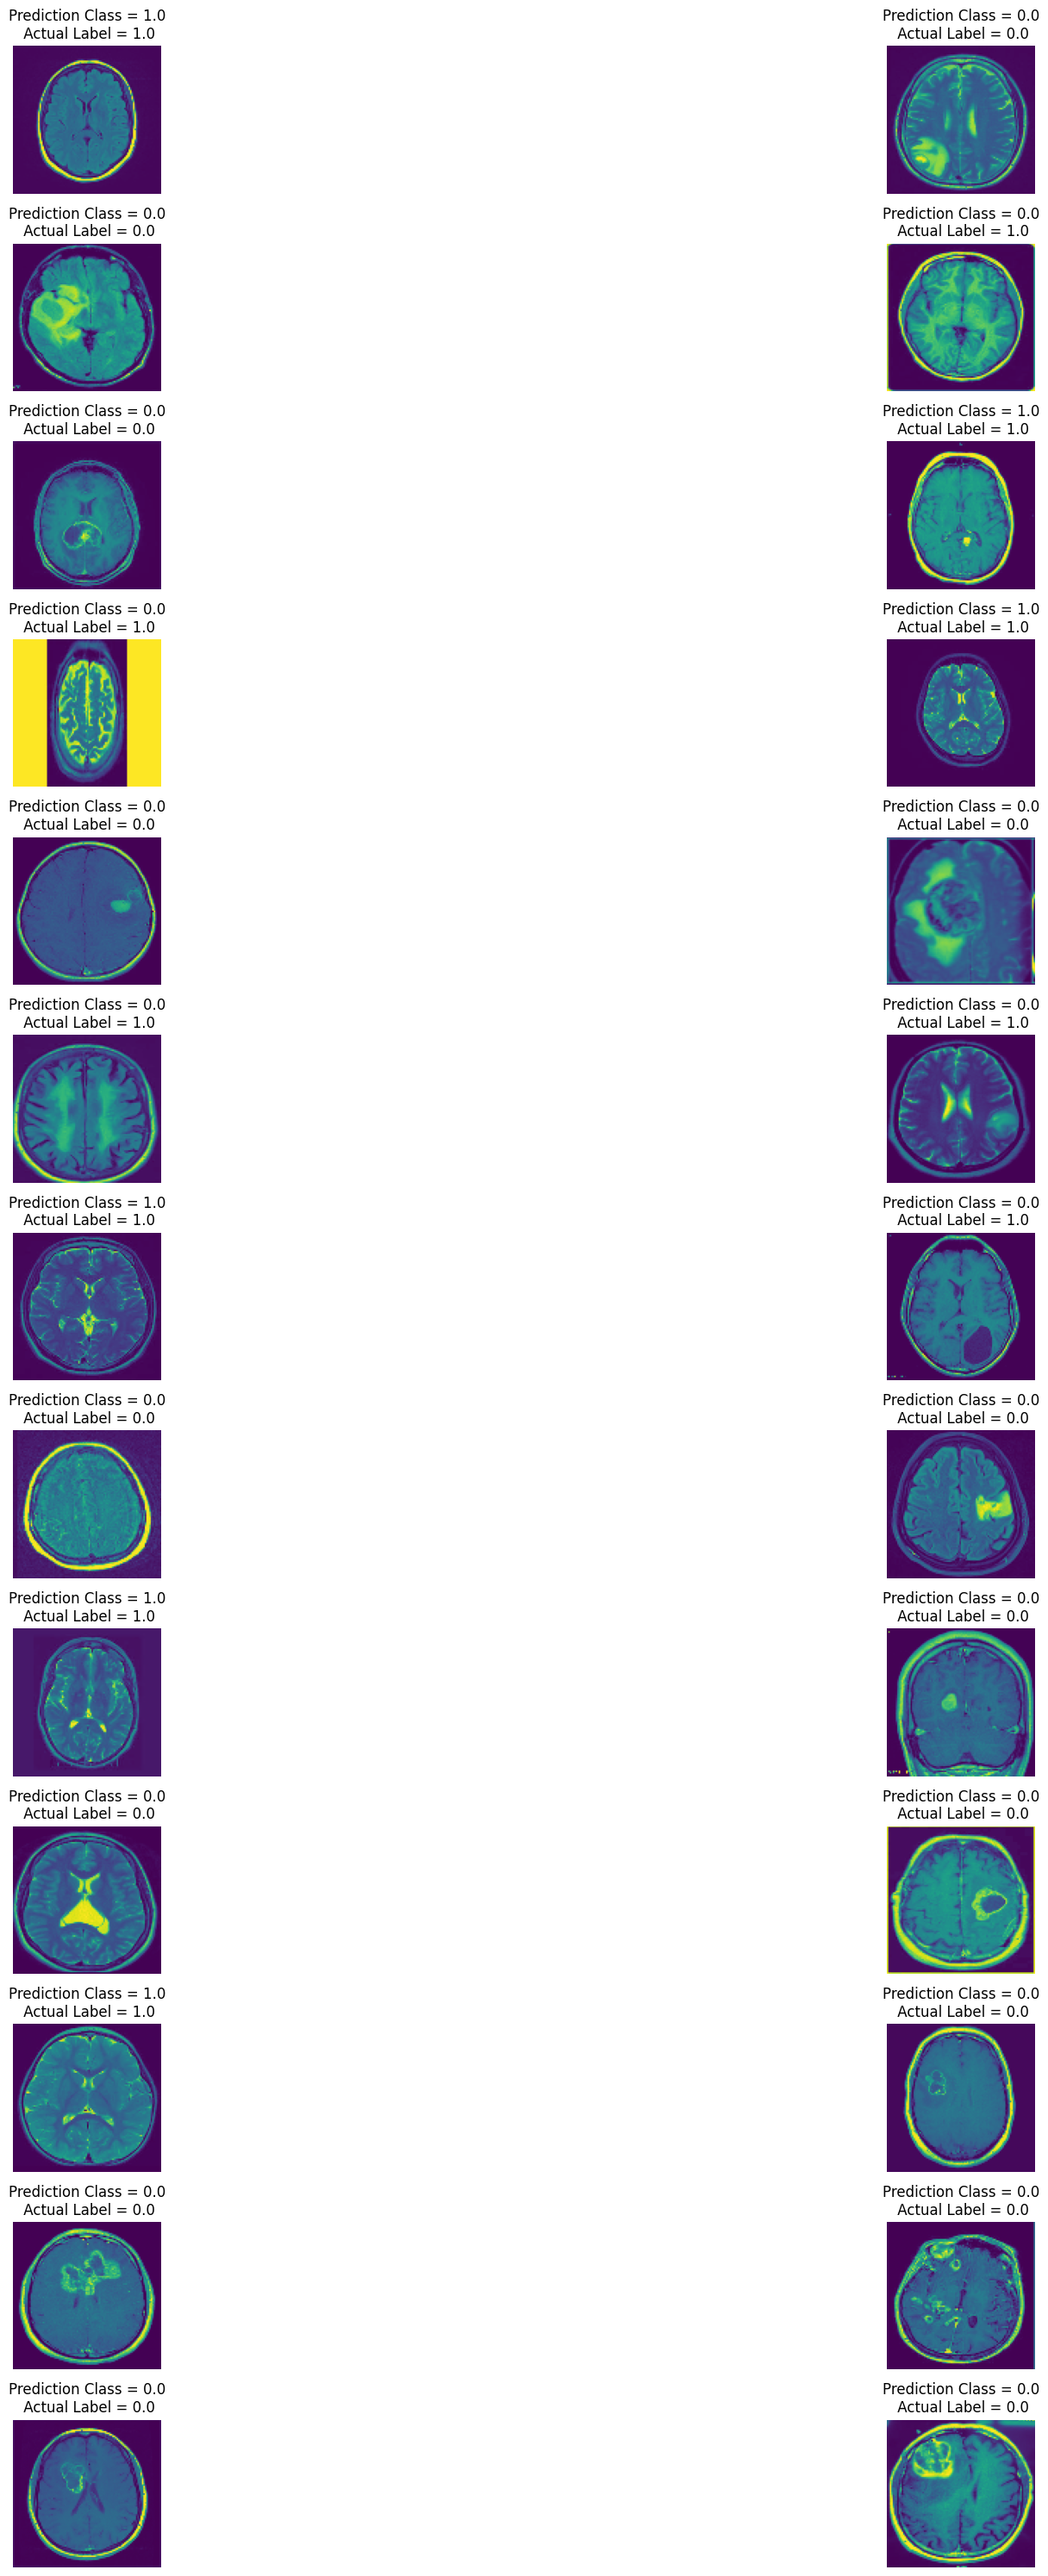

In [33]:
y_actual=np.argmax(y_test,axis=1)
L = 13
W = 2
fig, axes = plt.subplots(L, W, figsize = (30,30))
axes = axes.ravel()
for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i])
    axes[i].set_title(f"Prediction Class = {y_predicted[i]:0.1f}\n Actual Label = {y_actual[i]:0.1f}")
    axes[i].axis('off')
plt.subplots_adjust(wspace=0.1)
plt.tight_layout()